# 02 — Feature Engineering

**Input:** `data/processed/df_validated.parquet`  
**Output:** `data/processed/X_train.parquet`, `X_test.parquet`, `y_train.parquet`, `y_test.parquet`

Steps:
1. Derive business-driven features
2. Encode categoricals
3. Stratified train/test split
4. Feature correlation with target

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_parquet('data/processed/df_validated.parquet')
print(f'Loaded {len(df):,} rows')

Loaded 10,000 rows


## 1. Derived features

Each feature encodes a specific business hypothesis rather than a statistical transformation.

In [2]:
df = df.copy()

# Hypothesis: financial stress relative to income predicts churn
# better than balance alone (a €10k balance means different things
# for a €20k vs €100k salary customer)
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Hypothesis: slow product adoption relative to tenure signals disengagement
df['ProductsPerYear'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# Hypothesis: high-value customers (top balance quartile + multiple products)
# have distinct churn drivers — worth flagging explicitly
df['IsHighValue'] = (
    (df['Balance'] > df['Balance'].quantile(0.75)) &
    (df['NumOfProducts'] >= 2)
).astype(int)

print('Derived features added:')
print(df[['BalanceSalaryRatio', 'ProductsPerYear', 'IsHighValue']].describe().round(3))

Derived features added:
       BalanceSalaryRatio  ProductsPerYear  IsHighValue
count           10000.000        10000.000    10000.000
mean                1.055            0.446        0.124
std                 1.825            0.468        0.329
min                 0.000            0.100        0.000
25%                 0.000            0.167        0.000
50%                 0.498            0.286        0.000
75%                 1.251            0.500        0.000
max                18.939            4.000        1.000


## 2. Encode categoricals

France is the reference category for Geography — it's the largest group and the natural baseline for a French banking context.

In [3]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

FEATURE_COLS = [
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
    'BalanceSalaryRatio', 'ProductsPerYear', 'IsHighValue',
    'Geography_Germany', 'Geography_Spain', 'Gender_Male',
]

X = df[FEATURE_COLS]
y = df['Exited']

print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
X.head()

Feature matrix: 10,000 rows × 14 features


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductsPerYear,IsHighValue,Geography_Germany,Geography_Spain,Gender_Male
0,452,32,3,0.000000,1,0,0,24670.879088,0.000000,0.250000,0,False,False,False
1,785,44,9,0.000000,1,0,1,43507.971001,0.000000,0.100000,0,False,False,True
2,698,66,1,93435.541229,1,0,0,72196.873612,1.294159,0.500000,0,False,False,True
3,620,25,8,75903.776105,1,1,0,19349.894311,3.922494,0.111111,0,True,False,True
4,456,46,3,115511.592207,2,0,0,47119.204331,2.451424,0.500000,0,False,False,True


## 3. Stratified train / test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Confirm churn rate is preserved in both splits
print(f'Train  — {len(X_train):,} rows | churn rate: {y_train.mean():.1%}')
print(f'Test   — {len(X_test):,}  rows | churn rate: {y_test.mean():.1%}')

Train  — 8,000 rows | churn rate: 54.3%
Test   — 2,000  rows | churn rate: 54.4%


## 4. Feature correlation with target

Point-biserial correlation gives a quick first-pass ranking of feature relevance.

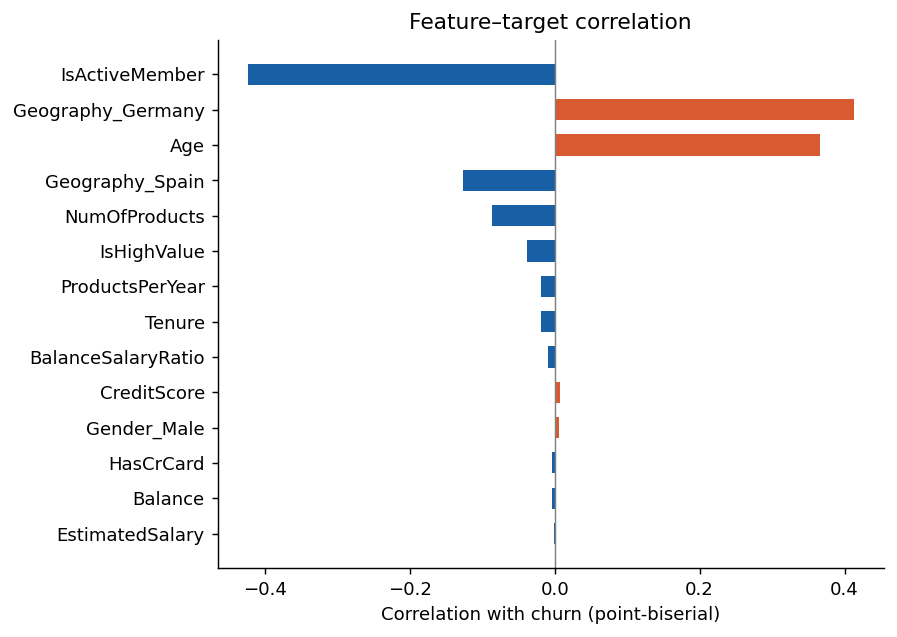

IsActiveMember       -0.423
Geography_Germany     0.413
Age                   0.366
Geography_Spain      -0.127
NumOfProducts        -0.087
IsHighValue          -0.038
ProductsPerYear      -0.019
Tenure               -0.018
BalanceSalaryRatio   -0.009
CreditScore           0.007
Gender_Male           0.007
HasCrCard            -0.004
Balance              -0.004
EstimatedSalary      -0.001


In [5]:
correlations = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)

colors = [('#D85A30' if v > 0 else '#185FA5') for v in correlations.values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(correlations.index, correlations.values, color=colors, height=0.6)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Correlation with churn (point-biserial)')
ax.set_title('Feature–target correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('reports/figures/02_feature_correlation.png', bbox_inches='tight')
plt.show()

print(correlations.round(3).to_string())

## Save splits

In [6]:
X_train.to_parquet('data/processed/X_train.parquet')
X_test.to_parquet('data/processed/X_test.parquet')
y_train.to_frame().to_parquet('data/processed/y_train.parquet')
y_test.to_frame().to_parquet('data/processed/y_test.parquet')

print('Saved train/test splits to data/processed/')

Saved train/test splits to data/processed/
